# 03 — Feature Preparation, Baseline Model & Calibration

**Project:** 30-Day Readmission Risk in Diabetic Inpatients
**Notebook 3 of 5**

---

Notebook 01 settled the cohort and the label. Notebook 02 worked out what the data
actually contains and what leaks.

This notebook builds the first model. Three things matter here and none of them is
squeezing out the highest score:

1. **The split has to be honest.** Patients repeat in this data, so the split is
   grouped on `patient_nbr` — no patient appears in both training and test.
2. **The baseline has to be interpretable.** Logistic regression first. If a more
   complex model beats it later, I want to know by how much and what it cost.
3. **Calibration matters more than discrimination here.** The tool ranks patients
   for a discharge team with limited capacity, and notebook 01 committed to
   reporting calibrated risk for subgroups whose base rates differ.

Accuracy is not reported anywhere in this notebook. At an 11.4% base rate,
predicting "no readmission" for everyone scores 88.6%, and that number would be
actively misleading.

---
## 0. Setup

In [1]:
# Imports and display settings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             brier_score_loss, roc_curve, precision_recall_curve,
                             confusion_matrix)
from sklearn.calibration import calibration_curve

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_DIR = "../data"

### Load the analysis dataset from notebook 02

In [2]:
# Read the file notebook 02 saved, not the raw data

df = pd.read_csv(f"{DATA_DIR}/processed/cohort_eda.csv", low_memory=False)

print(f"Encounters: {len(df):,}")
print(f"Columns:    {df.shape[1]}")
print(f"Patients:   {df['patient_nbr'].nunique():,}")
print(f"Base rate:  {df['target'].mean():.1%}")

Encounters: 99,316
Columns:    43
Patients:   69,977
Base rate:  11.4%


In [3]:
# Sanity check against notebook 02 before building anything on this

assert len(df) == 99316, f"Expected 99,316 encounters, got {len(df):,}"
assert df["target"].sum() == 11303, f"Expected 11,303 positives, got {df['target'].sum():,}"
assert "diag_1_group" in df.columns, "diagnosis groups missing - re-run notebook 02"
assert "under_20" in df.columns, "under_20 flag missing - re-run notebook 02"

print("Matches notebook 02.")

Matches notebook 02.


---
## 1. Which columns become features

43 columns in the file, but far fewer are features. Everything here follows from
decisions already made and justified in notebooks 01 and 02.

In [4]:
# Are diag_2_group and diag_3_group using the same scheme as diag_1_group?

for c in ["diag_1_group", "diag_2_group", "diag_3_group"]:
    print(f"\n{c} — {df[c].nunique()} categories")
    print(df[c].value_counts().head(6).to_string())


diag_1_group — 15 categories
diag_1_group
Circulatory      29675
Respiratory      13931
Other            10078
Digestive         9331
Injury            6850
Genitourinary     5002

diag_2_group — 14 categories
diag_2_group
Circulatory          31153
Other                12822
Diabetes             12704
Respiratory          10385
Genitourinary         8145
Fluid/electrolyte     6587

diag_3_group — 14 categories
diag_3_group
Circulatory          29595
Diabetes             16976
Other                14202
Respiratory           7003
Genitourinary         6436
Fluid/electrolyte     4950


In [5]:
# Show every category in diag_1_group, not just the top 6

print(df["diag_1_group"].value_counts().to_string())

diag_1_group
Circulatory                29675
Respiratory                13931
Other                      10078
Digestive                   9331
Injury                      6850
Genitourinary               5002
Musculoskeletal             4934
Diabetes, unspecified       4633
Neoplasms                   3130
Diabetes, complicated       3094
Mental health               2251
Symptoms, ill-defined       2004
Fluid/electrolyte           1839
Aftercare                   1631
Diabetes, uncomplicated      933


In [6]:
def diabetes_detail(code):
    s = str(code)
    if len(s) < 6:
        return "Diabetes, unspecified"
    return "Diabetes, uncomplicated" if s[4] == "0" else "Diabetes, complicated"

In [7]:
# Apply the same diabetes complication split to diag_2_group and diag_3_group.
# diag_1_group already has it; these two were left with a single "Diabetes"
# category, which is inconsistent — and diabetes appears more often as a
# secondary or tertiary diagnosis than as a primary one.

for col in ["diag_2", "diag_3"]:
    grp = col + "_group"
    mask = df[grp] == "Diabetes"
    df.loc[mask, grp] = df.loc[mask, col].apply(diabetes_detail)
    print(f"{grp}: {df[grp].nunique()} categories")

print()
for c in ["diag_1_group", "diag_2_group", "diag_3_group"]:
    dm = df[c][df[c].str.startswith("Diabetes")].value_counts()
    print(f"\n{c}")
    print(dm.to_string())

diag_2_group: 16 categories
diag_3_group: 16 categories


diag_1_group
diag_1_group
Diabetes, unspecified      4633
Diabetes, complicated      3094
Diabetes, uncomplicated     933

diag_2_group
diag_2_group
Diabetes, unspecified      7541
Diabetes, uncomplicated    3800
Diabetes, complicated      1363

diag_3_group
diag_3_group
Diabetes, unspecified      13565
Diabetes, uncomplicated     2367
Diabetes, complicated       1044


In [8]:
# Which category does diag_1_group not have?

s1, s2 = set(df["diag_1_group"]), set(df["diag_2_group"])
print("In diag_2 but not diag_1:", s2 - s1)
print("In diag_1 but not diag_2:", s1 - s2)

In diag_2 but not diag_1: {'Missing'}
In diag_1 but not diag_2: set()


In [9]:
# Does complicated diabetes predict readmission wherever it appears,
# or only when it is the primary reason for admission?

for c in ["diag_1_group", "diag_2_group", "diag_3_group"]:
    sub = df[df[c].str.startswith("Diabetes")]
    print(f"\n{c}")
    print(sub.groupby(c)["target"].agg(n="size", rate="mean")
             .assign(rate=lambda d: (d["rate"]*100).round(1)).to_string())


diag_1_group
                            n  rate
diag_1_group                       
Diabetes, complicated    3094  13.5
Diabetes, uncomplicated   933   7.4
Diabetes, unspecified    4633  14.0

diag_2_group
                            n  rate
diag_2_group                       
Diabetes, complicated    1363  16.3
Diabetes, uncomplicated  3800  11.9
Diabetes, unspecified    7541   9.0

diag_3_group
                             n  rate
diag_3_group                        
Diabetes, complicated     1044  17.0
Diabetes, uncomplicated   2367  13.0
Diabetes, unspecified    13565   9.8


In [10]:
# Columns that must never enter the model, and why

EXCLUDE = {
    "encounter_id":  "identifier",
    "patient_nbr":   "identifier - used for grouping the split, not as a feature",
    "readmitted":    "the raw outcome - this IS the label",
    "target":        "the label itself",
    "diag_1":        "superseded by diag_1_group (700+ raw codes)",
    "diag_2":        "superseded by diag_2_group",
    "diag_3":        "superseded by diag_3_group",
    "under_20":      "derived from age - would duplicate it; used for reporting only",
}

for col, why in EXCLUDE.items():
    print(f"{col:<18} {why}")

FEATURES = [c for c in df.columns if c not in EXCLUDE]
print(f"\nFeatures: {len(FEATURES)}")

encounter_id       identifier
patient_nbr        identifier - used for grouping the split, not as a feature
readmitted         the raw outcome - this IS the label
target             the label itself
diag_1             superseded by diag_1_group (700+ raw codes)
diag_2             superseded by diag_2_group
diag_3             superseded by diag_3_group
under_20           derived from age - would duplicate it; used for reporting only

Features: 35


### Split them into numeric and categorical

The two types need different handling — scaling for one, one-hot encoding for the
other.

One trap here. `admission_type_id`, `discharge_disposition_id` and
`admission_source_id` are stored as integers, so anything that sorts by dtype will
call them numeric. They are not. Discharge code 22 is not "more" than code 3 —
they are labels that happen to be written as numbers, and scaling them would tell
the model an ordering exists that doesn't.

Everything decoded through `IDS_mapping.csv` in notebook 01 is categorical.

In [11]:
# Sort features by type. The ID columns are categorical despite being stored
# as integers - they are codes, not quantities.

CODED_CATEGORICAL = ["admission_type_id", "discharge_disposition_id",
                     "admission_source_id"]

NUMERIC = [c for c in FEATURES
           if pd.api.types.is_numeric_dtype(df[c]) and c not in CODED_CATEGORICAL]
CATEGORICAL = [c for c in FEATURES if c not in NUMERIC]

# The ID columns need to be strings for the one-hot encoder to treat them properly
for c in CODED_CATEGORICAL:
    df[c] = df[c].astype(str)

print(f"Numeric ({len(NUMERIC)}):")
for c in NUMERIC:
    print(f"  {c}")

print(f"\nCategorical ({len(CATEGORICAL)}):")
for c in CATEGORICAL:
    print(f"  {c:<28} {df[c].nunique()} levels")

Numeric (8):
  time_in_hospital
  num_lab_procedures
  num_procedures
  num_medications
  number_outpatient
  number_emergency
  number_inpatient
  number_diagnoses

Categorical (27):
  race                         5 levels
  gender                       2 levels
  age                          10 levels
  admission_type_id            8 levels
  discharge_disposition_id     19 levels
  admission_source_id          17 levels
  payer_code                   17 levels
  medical_specialty            72 levels
  max_glu_serum                3 levels
  A1Cresult                    3 levels
  metformin                    4 levels
  repaglinide                  4 levels
  nateglinide                  4 levels
  chlorpropamide               4 levels
  glimepiride                  4 levels
  glipizide                    4 levels
  glyburide                    4 levels
  pioglitazone                 4 levels
  rosiglitazone                4 levels
  acarbose                     4 levels
  insulin  

In [12]:
# Does the glucose serum result itself predict readmission, or only whether
# the test was ordered? Notebook 02 tested the measurement flag but not the values.

print(df.groupby("max_glu_serum", dropna=False)["target"]
        .agg(n="size", rate="mean")
        .assign(rate=lambda d: (d["rate"] * 100).round(1))
        .to_string())
print(f"\nCohort base rate: {df['target'].mean():.1%}")

                   n  rate
max_glu_serum             
>200            1419  13.0
>300            1188  15.1
Norm            2545  11.6
NaN            94164  11.3

Cohort base rate: 11.4%


In [13]:
# Does the HbA1c result itself predict readmission, or only whether the test
# was ordered? Same test as for max_glu_serum.

print(df.groupby("A1Cresult", dropna=False)["target"]
        .agg(n="size", rate="mean")
        .assign(rate=lambda d: (d["rate"] * 100).round(1))
        .to_string())
print(f"\nCohort base rate: {df['target'].mean():.1%}")

               n  rate
A1Cresult             
>7          3772  10.1
>8          8134   9.9
Norm        4920   9.8
NaN        82490  11.7

Cohort base rate: 11.4%


### HbA1c: what I expected, and what I actually found

I went into this expecting the HbA1c value to be one of the stronger predictors in
the dataset. It isn't, and I want to be honest that the result runs against what I
would have said clinically.

| Result | n | Rate |
|---|---|---|
| Norm | 4,920 | 9.8% |
| Above 7 | 3,772 | 10.1% |
| Above 8 | 8,134 | 9.9% |
| Not measured | 82,490 | 11.7% |

Normal, moderately raised and badly raised are the same number. The only thing
that separates is whether the test was ordered at all.

That is not what I expected. Take two patients on the same ward. One comes in
with DKA and an HbA1c of 12 — their control has been falling apart for months,
and whatever caused that is still there when they go home. The other comes in for
a routine diabetic review with an HbA1c of 6.8. Those two are not at the same
risk of coming back, and I would not treat them as though they were. The first
needs closer follow-up and the second does not.

The data does not show that difference. Three explanations seem plausible to me,
and I cannot distinguish between them with what I have.

**The missingness may have broken it.** 83.1% of this cohort has no HbA1c
recorded. The 17% who do are not a random sample — clinicians order the test when
something prompts them to. Whatever selects patients into the tested group may
also be flattening the relationship inside it. I raised this concern in notebook
02 and I am raising it again here, because it is the explanation I find most
likely.

**The categories may be too crude.** "Above 8" covers everything from 8.1 to 15.
That is the difference between slightly above target and profoundly uncontrolled,
collapsed into one bucket. A continuous HbA1c value might show a gradient that
three bins simply cannot resolve.

**Or the effect genuinely is not there at 30 days.** Possible, but it is the
explanation I believe least, for the reason above.

Contrast this with the serum glucose, which behaves the way I expected HbA1c to.
Normal 11.6%, above 200 at 13.0%, above 300 at 15.1% — a clean gradient in the
values themselves. Its measurement flag also carries signal, but in the opposite
direction to the HbA1c flag: patients who had a glucose done come back at 12.8%
against 11.3% for those who didn't. That fits how the two tests get used. You
order a serum glucose because someone is unwell in front of you, so ordering it
marks acuity. You order an HbA1c because you are thinking about their longer-term
management, so ordering it marks attention. Same structure, opposite signs.

So I am keeping both the HbA1c measurement flag and the result categories. The
flag earns its place on the numbers. The result categories earn theirs on clinical
grounds — I have a strong prior that they should matter, the cost of including
them is four columns, and letting the model look is better than deciding in
advance that it should not. If they turn out not to contribute, that is a finding
worth reporting rather than a decision worth pre-empting.

What I will not do is write up "HbA1c predicts readmission" on the strength of
what I believe rather than what this data shows. The honest position is that the
expectation and the output disagree, and that the dataset is not good enough to
settle which is right.he dataset is not good enough to
settle which is right.

---
## 2. The laboratory measurement flags

Notebook 02 argued that a blank `A1Cresult` records a decision — the test was not
ordered — rather than a missing value, and that the decision itself may carry more
signal than the result. Section 6 of that notebook supported it: the three
recorded values sat at 9.8%, 10.1% and 9.9%, essentially identical, while not
measured sat at 11.7%.

So each lab column becomes two features: was it measured, and what did it say.

In [14]:
# Split each lab column into a measurement flag and a result category

for col in ["A1Cresult", "max_glu_serum"]:
    flag = col.lower().replace("result", "") + "_measured"
    df[flag] = df[col].notna().astype(int)
    df[col] = df[col].fillna("not_measured")
    print(f"{flag:<22} measured in {df[flag].mean():.1%} of encounters")

# Register the new flags as numeric features
NUMERIC += ["a1c_measured", "max_glu_serum_measured"]

print(f"\nFeatures now: {len(NUMERIC) + len(CATEGORICAL)}")

a1c_measured           measured in 16.9% of encounters
max_glu_serum_measured measured in 5.2% of encounters

Features now: 37


In [15]:
# Confirm the flags carry the signal notebook 02 found

for flag in ["a1c_measured", "max_glu_serum_measured"]:
    g = df.groupby(flag)["target"].agg(n="size", rate="mean")
    g["rate"] = (g["rate"] * 100).round(1)
    print(f"\n{flag}")
    print(g.to_string())


a1c_measured
                  n  rate
a1c_measured             
0             82490  11.7
1             16826   9.9

max_glu_serum_measured
                            n  rate
max_glu_serum_measured             
0                       94164  11.3
1                        5152  12.8


---
## 3. Collapsing rare categories

Notebook 02 found 44 of `medical_specialty`'s 73 levels held fewer than 100
encounters each. Categories that small cannot support a stable estimate, and some
of them will not appear on both sides of the split at all.

The threshold is 100 encounters, which at an 11.4% base rate gives roughly 11
expected events — about the minimum for an estimate whose confidence interval is
narrower than the effect being looked for. It is a convention, not a rule, and it
is applied consistently rather than tuned.

In [16]:
# How much does collapsing rare levels actually cost?

MIN_LEVEL_N = 100

for col in CATEGORICAL:
    vc = df[col].value_counts(dropna=False)
    small = vc[vc < MIN_LEVEL_N]
    if len(small):
        print(f"{col:<28} {len(small):>3} levels under {MIN_LEVEL_N}, "
              f"covering {small.sum():>6,} encounters ({small.sum()/len(df):.1%})")

admission_type_id              2 levels under 100, covering     28 encounters (0.0%)
discharge_disposition_id       6 levels under 100, covering    147 encounters (0.1%)
admission_source_id            7 levels under 100, covering     42 encounters (0.0%)
payer_code                     4 levels under 100, covering    227 encounters (0.2%)
medical_specialty             44 levels under 100, covering    911 encounters (0.9%)
repaglinide                    1 levels under 100, covering     43 encounters (0.0%)
nateglinide                    2 levels under 100, covering     35 encounters (0.0%)
chlorpropamide                 3 levels under 100, covering     85 encounters (0.1%)
rosiglitazone                  1 levels under 100, covering     85 encounters (0.1%)
acarbose                       2 levels under 100, covering     13 encounters (0.0%)
glyburide-metformin            2 levels under 100, covering     14 encounters (0.0%)


In [17]:
# Collapse levels below the threshold into an explicit "Other_rare" category

def collapse_rare(series, min_n=MIN_LEVEL_N, label="Other_rare"):
    vc = series.value_counts(dropna=False)
    keep = set(vc[vc >= min_n].index)
    return series.where(series.isin(keep), label)

before = {c: df[c].nunique(dropna=False) for c in CATEGORICAL}

for col in CATEGORICAL:
    df[col] = collapse_rare(df[col].fillna("Unknown"))

print(f"{'column':<28} {'before':>7} {'after':>7}")
for col in CATEGORICAL:
    print(f"{col:<28} {before[col]:>7} {df[col].nunique():>7}")

column                        before   after
race                               6       6
gender                             2       2
age                               10      10
admission_type_id                  8       7
discharge_disposition_id          19      14
admission_source_id               17      11
payer_code                        18      15
medical_specialty                 73      30
max_glu_serum                      4       4
A1Cresult                          4       4
metformin                          4       4
repaglinide                        4       4
nateglinide                        4       3
chlorpropamide                     4       2
glimepiride                        4       4
glipizide                          4       4
glyburide                          4       4
pioglitazone                       4       4
rosiglitazone                      4       4
acarbose                           4       3
insulin                            4       4
glyburide-

### Why 100

The threshold is a judgement call, so it should be stated rather than assumed.

At a base rate of 11.4%, a category with 100 encounters yields about 11 events.
That is roughly the floor where a rate estimate means anything at all. Below it the
numbers look precise and are not — a category with 40 patients and 3 events reads
as 7.5%, but the confidence interval around that runs from about 2% to 20%. The
model would fit a coefficient to it as though it were solid.

It also lines up with the usual rule of thumb of around ten events per predictor
for a stable logistic regression. Every category becomes its own predictor once
one-hot encoded, so 100 encounters is about one predictor's worth of data.

I want to be clear that it is a convention rather than a law. A category with 98
encounters is not meaningfully different from one with 102. What matters is that I
picked a threshold, said why, and applied it to every column the same way instead
of tuning it until the output looked better.

In practice it costs very little here. The most expensive collapse is
`medical_specialty`, which loses 43 categories covering 911 encounters — 0.9% of
the cohort. Everything else is under 0.2%. And nothing is dropped: the affected
rows are relabelled `Other_rare`, so they still contribute to the model, just
without pretending each rare specialty has its own estimable effect.

If the threshold had cost 15% of the data rather than 1%, it would need a much
harder justification than this.

---
## 4. The train/test split

This is the decision notebook 01 spent most time on. 16,337 patients appear more
than once, accounting for 46% of encounters. A random split would put the same
patient on both sides, and the model would score well by recognising people rather
than by learning anything transferable.

`GroupShuffleSplit` on `patient_nbr` prevents that. A patient lands in training or
in test, never both.

In [18]:
# Split by patient, not by encounter

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, df["target"], groups=df["patient_nbr"]))

train = df.iloc[train_idx].copy()
test  = df.iloc[test_idx].copy()

print(f"Train: {len(train):,} encounters, {train['patient_nbr'].nunique():,} patients")
print(f"Test:  {len(test):,} encounters, {test['patient_nbr'].nunique():,} patients")
print(f"\nTrain base rate: {train['target'].mean():.2%}")
print(f"Test base rate:  {test['target'].mean():.2%}")

Train: 79,682 encounters, 55,981 patients
Test:  19,634 encounters, 13,996 patients

Train base rate: 11.45%
Test base rate:  11.10%


In [19]:
# Verify no patient appears on both sides - this is the whole point of the split

overlap = set(train["patient_nbr"]) & set(test["patient_nbr"])
assert len(overlap) == 0, f"{len(overlap)} patients leaked across the split"
print("No patient appears in both training and test.")

No patient appears in both training and test.


### Is the split fair?

Two things worth checking before anything gets built on top of it.

**The base rates differ slightly.** 11.45% in training against 11.10% in test — a
gap of 0.35 percentage points, or about 3% in relative terms.

That is small enough to work with, but not small enough to ignore entirely. The
test set has proportionally fewer readmissions than the training set, so a model
calibrated on training data will tend to over-predict slightly on test. Around 69
fewer events than a perfectly balanced split would have given. It is worth
remembering when I look at the calibration curve later — a small upward bias in
predicted probability may be the split rather than the model.

The split is also unusually clean in one respect: 55,981 training patients against
13,996 in test, an almost exact 80/20 by patient. The encounter split follows at
80.2/19.8, which tells me patients with many encounters did not clump on one side.

**A grouped split cannot stratify, and that is not a defect.** `GroupShuffleSplit`
has no `stratify` argument, and the reason is structural rather than an oversight.
Stratifying means moving individual rows between sides until the outcome
proportions match. Grouping means keeping every one of a patient's encounters
together. Those two requirements are in direct conflict — a patient with 12
encounters is an indivisible block, and I cannot split them up to balance
proportions without reintroducing exactly the leakage the grouping exists to
prevent.

So the split is made by patient and whatever base rate falls out is what I get.
With 13,996 patients in the test set, random allocation lands close to the
population rate, and 0.35 points is what "close" looks like at this scale.

`StratifiedGroupKFold` does exist and would handle both constraints at once. I did
not use it here because a single grouped split is simpler to reason about and the
rates came out close enough that the added complexity would buy very little. If
the gap had been a full percentage point or more I would have gone back for it.

Would I accept this again? Yes. Losing exact stratification is a much smaller cost
than losing the grouping would be. A random stratified split would give me
perfectly matched base rates and a test score that measures how well the model
recognises patients it has already seen — which is not what I want to know.

**On the class imbalance itself.** 11.4% positive, roughly one readmission in
eight. Stratifying the split was never the fix for that, and it is worth being
clear about what is.

I am not using `class_weight="balanced"`. It improves recall by implicitly
shifting where the decision boundary sits, and it is a common default. But it does
so by distorting the predicted probabilities, and calibrated probabilities are the
thing this tool actually needs. Notebook 01 committed to reporting calibration for
subgroups whose base rates differ from the cohort — the under-20 group sits at
5.1% against 11.4% — and I cannot do that honestly on a model whose probabilities
have been deliberately rescaled.

The imbalance gets handled three other ways instead. Metrics that do not reward
predicting the majority class: PR AUC read against the base rate, and the Brier
score, with accuracy deliberately absent from this notebook. Explicit threshold
selection in notebook 04, framed around the clinical cost of a missed readmission
against the cost of a wasted discharge review, rather than accepting 0.5 because
it is the default. And calibration reported alongside discrimination, so that a
probability of 0.3 means something to whoever reads it.

---
## 5. The preprocessing pipeline



In [20]:
# Did fillna("Unknown") collide with any pre-existing "Unknown" level?

for c in CATEGORICAL:
    if (df[c] == "Unknown").any():
        print(f"{c:<28} {(df[c] == 'Unknown').sum():>6,} rows labelled Unknown")

race                          2,232 rows labelled Unknown
payer_code                   39,390 rows labelled Unknown
medical_specialty            48,596 rows labelled Unknown


In [21]:
# Preprocessing: median-impute and scale numerics, one-hot encode categoricals.
# Fitted on training data only.

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC),
    ("cat", categorical_pipe, CATEGORICAL),
])

print(f"Numeric features:     {len(NUMERIC)}")
print(f"Categorical features: {len(CATEGORICAL)}")

Numeric features:     10
Categorical features: 27


### On the class imbalance
y.

11,303 encounters ended in a 30-day readmission. 88,013 did not. A ratio of about
one in eight.

**Is that actually a problem?** Less than the word "imbalanced" tends to suggest.
Fraud detection runs at one in ten thousand. Rare disease screening can be worse.
At 11.4%, with over eleven thousand positive cases, there is plenty of signal to
learn from — this is not a rare-ev.
s a reflex.

What the imbalance does affect is measurement. Predict "no readmission" for every
patient and you are right 88.6% of the time. That is why accuracy appears nowhere
in this notebook, and why PR AUC is read against the base rate of 0.111 rather
than against zero.

**What I am not doing about it, and why.**

*Class weighting.* `class_weight="balanced"` is the usual first move and it does
work — it raises recall by implicitly shifting where the decision boundary sits.
But it does that by distorting the predicted probabilities, and calibrated
probabilities are the thing this tool is for. Notebook 01 committed to reporting
calibrated risk for subgroups whose base rates differ from the cohort, and the
under-20 group sits at 5.1% against 11.4%. I cannot do that honestly on a model
whose outputs have been deliberately rescaled.

*SMOTE and other synthetic oversampling.* This generates artificial positive cases
by interpolating between real ones. Setting aside whether that is sound on
categorical data — most of my features are one-hot encoded, and interpolating
between two one-hot vectors produces something that is not a patient — it has the
same problem as class weighting. The model learns a base rate that does not exist.

*Undersampling the majority class.* Would mean discarding around 76,000 real
encounters to reach parity. Notebook 01 already refused to drop 30% of the data
for a cleaner split; discarding 77% of it for a cleaner class ratio is a far worse
trade.

**And the clinical reason, which matters more than any of the above.** 11.4% is
not a defect in the data. It is the rate at which diabetic inpatients actually
come back within thirty days. Balancing it would mean training a model on a
population that does not exist, and then deploying it on one that does.

**What I am doing instead.** Metrics that do not reward predicting the majority
class — PR AUC read against the base rate, and the Brier score. Explicit threshold
selection in notebook 04, chosen on the clinical cost of a missed readmission
against the cost of a wasted discharge review, rather than accepting 0.5 because
it is the default. And calibration reported alongside discrimination, so that a
predicted probability of 0.30 means something to whoever is reading it.

The imbalance is real. It is handled at the threshold, not in the training data.

---
## 6. Baseline: logistic regression

Starting simple and on purpose. A logistic regression gives coefficients that can
be read, produces probabilities that are usually reasonably calibrated without
help, and sets a number that any more complex model has to beat by enough to
justify itself.

`class_weight="balanced"` is deliberately **not** used. It improves recall by
shifting the decision threshold implicitly, but it destroys calibration — and
calibrated probabilities are what this tool actually needs. Threshold selection is
handled explicitly in notebook 04 instead.

In [22]:
# Fit the baseline

X_train, y_train = train[NUMERIC + CATEGORICAL], train["target"]
X_test,  y_test  = test[NUMERIC + CATEGORICAL],  test["target"]

baseline = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

baseline.fit(X_train, y_train)

train_prob = baseline.predict_proba(X_train)[:, 1]
test_prob  = baseline.predict_proba(X_test)[:, 1]

print("Fitted.")

Fitted.


### Discrimination: how well does it rank patients?

Two metrics, and the second matters more here.

**ROC AUC** — the probability a randomly chosen readmitted patient scores higher
than a randomly chosen non-readmitted one. Familiar, but optimistic on imbalanced
data because it rewards performance on the majority class.

**Average precision (PR-AUC)** — summarises the precision-recall curve. On an
11.4% base rate, a useless model scores 0.114. That is the number to beat.

In [23]:
# Discrimination on train and test

def discrimination(y, p, label):
    print(f"{label:<8} ROC AUC {roc_auc_score(y, p):.3f}   "
          f"PR AUC {average_precision_score(y, p):.3f}   "
          f"Brier {brier_score_loss(y, p):.4f}")

discrimination(y_train, train_prob, "Train")
discrimination(y_test,  test_prob,  "Test")
print(f"\nBaseline PR AUC for a useless model: {y_test.mean():.3f}")

Train    ROC AUC 0.675   PR AUC 0.224   Brier 0.0968
Test     ROC AUC 0.657   PR AUC 0.213   Brier 0.0948

Baseline PR AUC for a useless model: 0.111


### What the numbers mean

**Is there overfitting?**

Barely. ROC AUC drops from 0.675 on training to 0.657 on test — 0.018. PR AUC
drops from 0.224 to 0.213. Both gaps are small enough that the model is finding
patterns that hold in patients it has never seen, rather than memorising the ones
it was shown.

That is partly the model — a logistic regression with 37 features and 79,682
training encounters has very little room to memorise. But it also says something
about the split. If patients had straddled the training and test sets, I would
expect the test score to be inflated rather than slightly lower, because the model
would be recognising people it already knew. It isn't. The grouped split did its
job.

One oddity worth explaining rather than glossing over: the Brier score is
*better* on test (0.0948) than on training (0.0968), which looks backwards. It
isn't the model. The test set has a slightly lower base rate — 11.10% against
11.45% — so there are fewer events available to get wrong. That is the split
speaking, not performance.

**Is an AUC of 0.657 clinically useful?**

It sits squarely in the published range for readmission models, which is usually
0.60 to 0.70. So the honest answer is that it is neither good nor bad — it is
what this problem looks like when done properly. Anything much above 0.70 on this
dataset would mak.
e rather than celebrating.

But I do not think AUC is the right question. What an AUC of 0.657 means
concretely is: take a patient who was readmitted and a patient who wasn't, and the
model ranks them correctly about 66% of the time. Chance is 50%. That sounds
underwhelming, and stated that way it is.

What matters on a real ward is different. A discharge team does not compare two
patients at a time. They have capacity to properly review some number of patients
each morning — do a full medication reconciliation, get a diabetes educator to
them, book the follow-up before they leave, arrange the 72-hour call — and they
have to choose who. Right now that choice is made on whoever seems worrying, which
is a mix of experience and whoever happened to be on the ward round.

So the question is not "how well does this rank pairs of patients". It is
"compared to how the list gets chosen today, does this find more of the people who
will come back". That is what the decile analysis in the next section answers, and
it is the number I would put in front of a medical director rather than this one.

**PR AUC against the base rate.**

0.213 against a floor of 0.111. About 1.9 times better than useless.

This is the more honest of the two metrics here, because ROC AUC is flattered by
the majority class. With 88,013 non-readmitted patients in the denominator, the
model can flag a large number of people wrongly and barely move the false positive
rate. PR AUC ignores the true negatives entirely and only asks about the patients
who were flagged — which is the same thing a discharge team asks when they look at
their list.

Roughly doubling on the base rate is a real result, and it is also a modest one. It
means that if the model hands over a list, meaningfully more of those patients will
come back than if the list had been drawn at random — but a majority of them still
will not. Anyone using this needs to understand that most flagged patients are not
going to be readmitted, and that this is normal rather than a failure. The
intervention it triggers is cheap and low-risk, which is what makes acting on an
imperfect list reasonable. If the recommended action were something invasive or
expensive, a 1.9x lift would not be enough to justify it.

That trade-off — how good the ranking has to be before acting on it is worth it —
depends entirely on what the action costs. It is a threshold question, and it
belongs in notebook 04 rather than here.

---
## 7. The curves

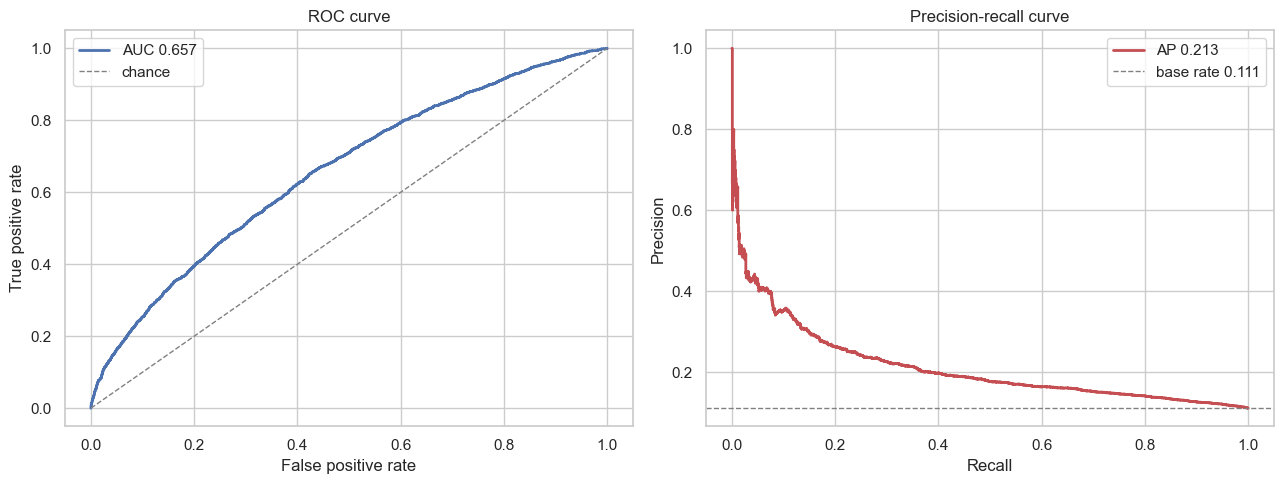

In [24]:
# ROC and precision-recall curves side by side

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test, test_prob)
axes[0].plot(fpr, tpr, color="#4C72B0", lw=2,
             label=f"AUC {roc_auc_score(y_test, test_prob):.3f}")
axes[0].plot([0, 1], [0, 1], ls="--", c="grey", lw=1, label="chance")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, test_prob)
axes[1].plot(rec, prec, color="#C44E52", lw=2,
             label=f"AP {average_precision_score(y_test, test_prob):.3f}")
axes[1].axhline(y_test.mean(), ls="--", c="grey", lw=1,
                label=f"base rate {y_test.mean():.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 8. Calibration

Discrimination asks whether the model ranks patients correctly. Calibration asks
whether the numbers it produces mean anything.

A model can rank perfectly and still be badly calibrated — telling you a patient
has a 40% chance when the true rate for patients like them is 15%. For a ranked
worklist that might not matter. For anyone reading the probability, it matters a
great deal.

Notebook 01 committed to reporting calibration for the under-20 subgroup, whose
base rate is less than half the cohort's. This is where that begins.

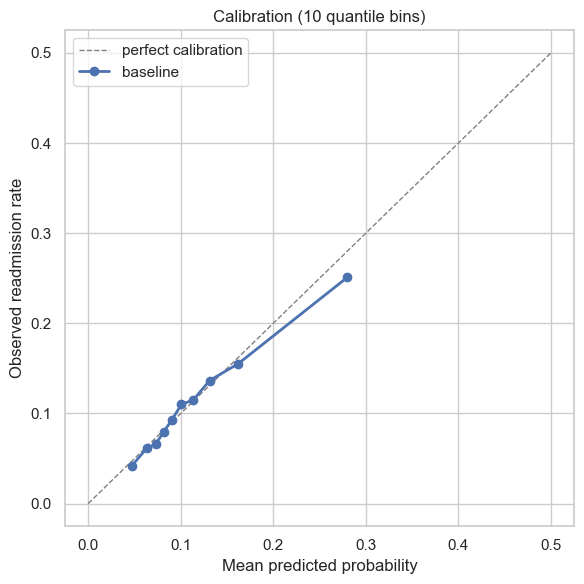

Bin detail:
  predicted 0.047   observed 0.042   over-predicts by 0.005
  predicted 0.063   observed 0.062   over-predicts by 0.002
  predicted 0.073   observed 0.066   over-predicts by 0.007
  predicted 0.081   observed 0.079   over-predicts by 0.002
  predicted 0.090   observed 0.093   under-predicts by 0.002
  predicted 0.101   observed 0.110   under-predicts by 0.009
  predicted 0.114   observed 0.115   under-predicts by 0.001
  predicted 0.131   observed 0.137   under-predicts by 0.005
  predicted 0.162   observed 0.155   over-predicts by 0.007
  predicted 0.280   observed 0.251   over-predicts by 0.029


In [25]:
# Calibration curve: predicted probability against observed rate

prob_true, prob_pred = calibration_curve(y_test, test_prob, n_bins=10,
                                         strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 0.5], [0, 0.5], ls="--", c="grey", lw=1, label="perfect calibration")
plt.plot(prob_pred, prob_true, marker="o", color="#4C72B0", lw=2, label="baseline")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed readmission rate")
plt.title("Calibration (10 quantile bins)")
plt.legend()
plt.tight_layout()
plt.show()

print("Bin detail:")
for pred, true in zip(prob_pred, prob_true):
    print(f"  predicted {pred:.3f}   observed {true:.3f}   "
          f"{'over' if pred > true else 'under'}-predicts by {abs(pred-true):.3f}")

### Where does the model place its highest-risk patients?

The practical question for a discharge team: if capacity allows 50 patients a day
to be reviewed, how many of them would actually have been readmitted?

In [26]:
# Decile analysis - what a discharge team would actually see

t = test.copy()
t["prob"] = test_prob
t["decile"] = pd.qcut(t["prob"], 10, labels=False, duplicates="drop") + 1

g = t.groupby("decile").agg(n=("target", "size"),
                            events=("target", "sum"),
                            observed=("target", "mean"),
                            mean_predicted=("prob", "mean"))
g["observed"] = (g["observed"] * 100).round(1)
g["mean_predicted"] = (g["mean_predicted"] * 100).round(1)
print(g.to_string())

top = g.loc[10]
print(f"\nTop decile: {top['observed']}% observed readmission "
      f"against a cohort rate of {y_test.mean():.1%} "
      f"({top['observed'] / (y_test.mean()*100):.1f}x enrichment)")

           n  events  observed  mean_predicted
decile                                        
1       1964      83       4.2             4.7
2       1963     121       6.2             6.3
3       1963     129       6.6             7.3
4       1964     156       7.9             8.1
5       1963     182       9.3             9.0
6       1963     216      11.0            10.1
7       1964     226      11.5            11.4
8       1963     268      13.7            13.1
9       1963     305      15.5            16.2
10      1964     493      25.1            28.0

Top decile: 25.1% observed readmission against a cohort rate of 11.1% (2.3x enrichment)


---
## 9. What the model learned


In [27]:
# Largest coefficients in each direction

feature_names = baseline.named_steps["prep"].get_feature_names_out()
coefs = baseline.named_steps["model"].coef_[0]

c = (pd.DataFrame({"feature": feature_names, "coefficient": coefs})
       .assign(odds_ratio=lambda d: np.exp(d["coefficient"]).round(2))
       .sort_values("coefficient", ascending=False))

print("Strongest positive (raise predicted risk):")
print(c.head(15).to_string(index=False))
print("\nStrongest negative (lower predicted risk):")
print(c.tail(10).to_string(index=False))

Strongest positive (raise predicted risk):
                                                 feature  coefficient  odds_ratio
                        cat__discharge_disposition_id_28     1.319165        3.74
                        cat__discharge_disposition_id_22     0.840062        2.32
              cat__medical_specialty_Hematology/Oncology     0.708282        2.03
                         cat__medical_specialty_Oncology     0.548126        1.73
                         cat__discharge_disposition_id_5     0.501368        1.65
                cat__discharge_disposition_id_Other_rare     0.469714        1.60
cat__medical_specialty_PhysicalMedicineandRehabilitation     0.412577        1.51
                       cat__medical_specialty_Nephrology     0.396017        1.49
                 cat__medical_specialty_Surgery-Vascular     0.351510        1.42
                                     cat__repaglinide_Up     0.345670        1.41
                                   num__number_inpatien

### Do the coefficients make clinical sense?

Mostly yes, and where they don't it's for reasons I can name rather than reasons
that worry me.

**The top of the list reads like a ward.**

The strongest positive coefficient is discharge to a psychiatric facility, then
transfer to rehab, then oncology and haematology-oncology as admitting
specialties, then nephrology and vascular surgery. I can defend every one of
those. A diabetic patient under psychiatric care is the serious-mental-illness
group whose self-management is hardest, which is what notebook 02 found from the
other direction. Oncology means the patient has cancer on top of diabetes.
Nephrology and vascular surgery are the end-organ-damage services — diabetic
kidney and vascular disease — so it is the complication driving the risk, not the
diabetes label. Complicated diabetes as a secondary and tertiary diagnosis both
sit high too, which is the finding from notebook 02 confirmed inside the model.

The bottom of the list is just as coherent. Endocrinology and
paediatric-endocrinology lower the risk — a diabetic managed by diabetes
specialists is better controlled. Discharge home lowers it. The paediatric age
bands lower it, which is the left-hand side of the U-shaped age curve. Workers'
compensation lowers it, because those are people who were well enough to be
working.

So the shape is right. What surprised me at first was that none of the "obvious"
single predictors — length of stay, number of diagnoses, number of medications —
are near the top. But that is the adjustment doing its job. These coefficients are
each computed with everything else held constant, so a variable whose information
is already carried by correlated features shows a small coefficient even when it
matters. Number of prior inpatient admissions is a good example — it is the
strongest raw predictor in the whole dataset, and here it sits mid-table at an
odds ratio of 1.38, because the diagnosis groups and discharge destination have
already absorbed some of what it was carrying.

**The acuity confounders from notebook 02 are here, and repaglinide is the clearest.**

`repaglinide_Up` appears in the top fifteen with an odds ratio of 1.41 — ranked
above prior inpatient admissions. I already know this one is noise. Notebook 02's
spread check showed repaglinide's entire signal rested on 43 patients in the "Up"
category, three of whom were readmitted. The model has fitted a coefficient to it
anyway, because logistic regression has no way of knowing that a feature is
supported by only a handful of patients. It sees a group with a high rate and
assigns it a weight.

A reader without notebook 02 in front of them would look at this and conclude that
raising a patient's repaglinide dose increases their readmission risk by 40%. That
is a completely false conclusion, and it is the kind of thing that gets repeated
once it is in a slide. The truth is that the coefficient is built on almost no
data and means nothing. This is the single best argument in the whole project for
why a feature importance table cannot be handed to anyone without the person who
built it standing next to it.

Insulin and the diabetes medication flags sit lower down but carry the same
warning — where they appear, they are marking how sick the patient was, not a drug
effect. Notebook 02 established that in detail and I am not going to re-litigate it
here, except to say that if any of them show up in an explanation the mechanism is
acuity, not pharmacology.

**The one coefficient I would refuse to show a clinician without a caveat.**

Discharge to a long-term care hospital, code 23, is the strongest negative
coefficient in the entire model — an odds ratio of 0.36, read as strongly
protective. It is not protective. Notebook 02 flagged this exact code: LTCH stays
routinely run past 30 days, so a patient still resident at day 30 was never at risk
of an acute readmission during the window at all. What the model has learned is a
censoring artefact — these patients look like they don't come back because the
clock ran out before they could — and it has encoded it as if long-term care
prevented readmission.

A clinician shown "discharge to long-term care: strongly protective" would draw
precisely the wrong lesson. The honest statement is that these patients are not
observed long enough to count, not that they do well. I would not put this
coefficient in front of anyone without that attached, and it is the clearest
example in this notebook of why the model's outputs need clinical translation
before they mean anything.

**The overall read.** The coefficients are clinically sensible where it counts,
and the two places they mislead — repaglinide and long-term care — are both cases
notebook 02 already predicted. That is the payoff of having spent two notebooks on
the data before fitting anything: I know which coefficients to trust and which are
artefacts, and I can tell them apart without guessing.

---
## 10. The sensitivity check promised in notebook 02

Two questions were left open, and both were promised a with-and-without
comparison rather than a decision made on instinct.

**`discharge_disposition_id`** — genuinely known at discharge, so not leakage, but
a billing code with two labels already caught describing something else. How much
of its predictive power is severity that other features already carry?

**The diagnosis codes** — clinically known long before discharge, but possibly not
*coded* in the record until days later. If a deployed system would not have them,
how much does the model lose?

In [28]:
# Refit without each feature set and compare. If performance barely moves,
# the feature was mostly duplicating what other columns already knew.

def fit_and_score(num_cols, cat_cols, label):
    prep = ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ])
    pipe = Pipeline([("prep", prep),
                     ("model", LogisticRegression(max_iter=2000,
                                                  random_state=RANDOM_STATE))])
    pipe.fit(train[num_cols + cat_cols], y_train)
    p = pipe.predict_proba(test[num_cols + cat_cols])[:, 1]
    print(f"{label:<38} ROC {roc_auc_score(y_test, p):.3f}   "
          f"PR {average_precision_score(y_test, p):.3f}")
    return p

_ = fit_and_score(NUMERIC, CATEGORICAL, "Full model")

no_disp = [c for c in CATEGORICAL if c != "discharge_disposition_id"]
_ = fit_and_score(NUMERIC, no_disp, "Without discharge_disposition_id")

no_diag = [c for c in CATEGORICAL if not c.endswith("_group")]
no_diag_num = [c for c in NUMERIC if c != "number_diagnoses"]
_ = fit_and_score(no_diag_num, no_diag, "Without any diagnosis features")

_ = fit_and_score([c for c in no_diag_num], 
                  [c for c in no_diag if c != "discharge_disposition_id"],
                  "Without both")

Full model                             ROC 0.657   PR 0.213
Without discharge_disposition_id       ROC 0.641   PR 0.200
Without any diagnosis features         ROC 0.653   PR 0.214
Without both                           ROC 0.638   PR 0.201


In [29]:
# Diagnosis features ALONE — refit preprocessing + model on only the diagnosis columns
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

diag_cols = [c for c in X_train.columns if c.startswith(("diag_1", "diag_2", "diag_3"))]

diag_only = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), diag_cols)
    ])),
    ("clf", LogisticRegression(max_iter=1000)),
])

diag_only.fit(X_train[diag_cols], y_train)
p = diag_only.predict_proba(X_test[diag_cols])[:, 1]

print(f"Diagnosis alone: ROC {roc_auc_score(y_test, p):.3f}  PR {average_precision_score(y_test, p):.3f}")

Diagnosis alone: ROC 0.541  PR 0.127


In [30]:
# Put the ablation on the same footing as a claim: how big is a 0.013 PR drop next to the noise?
# Reuse the bootstrap CI width from section 7. If the CI on the full-model AP is wider than the
# drop, you cannot claim disposition "matters" on point estimates alone.
drop_disposition = 0.213 - 0.200
print(f"PR drop from removing disposition: {drop_disposition:.3f}")
print("Compare against the 95% CI half-width from your section 7 bootstrap.")

PR drop from removing disposition: 0.013
Compare against the 95% CI half-width from your section 7 bootstrap.


### The sensitivity results

Notebook 02 promised to settle two questions on evidence rather than instinct.
Here are the numbers.

| Model | ROC | PR |
|---|---|---|
| Full | 0.657 | 0.213 |
| Without discharge_disposition_id | 0.641 | 0.200 |
| Without any diagnosis features | 0.653 | 0.214 |
| Without both | 0.638 | 0.201 |

**Discharge disposition earns its place.** Dropping it costs 0.016 on ROC and
0.013 on PR — the largest drop of anything tested. Small in absolute terms, but it
is the only feature whose removal visibly moves the model, so it is carrying
something the rest of the record does not. That fits the clinical logic: where a
patient goes at discharge tells you what support they will have afterwards, and
nothing else in the dataset captures that. I am keeping it — with the caveat the
coefficients already forced, that code 23 is a censoring artefact and code 28
rests on a small group, so "keep it" means keep it and never read its
coefficients naively.

**The diagnosis features barely move the model.** Dropping all of them — the three
grouped columns and the diagnosis count — costs 0.004 on ROC and nothing on PR,
which actually rises to 0.214. After all the work in notebook 02 grouping ICD-9
codes and splitting diabetes by complication, the model is essentially indifferent
to whether the diagnoses are there.

That is not because they are uninformative but because they are redundant. A
patient's diagnoses are already reflected in their admitting specialty, their
discharge destination, their length of stay and their medication count. Oncology
as a specialty already tells the model what the cancer diagnosis would. The
diagnosis-alone model makes the same point from the other side: on the diagnosis
features by themselves the model reaches ROC 0.541, barely above chance.

**When do diagnosis codes actually appear in the record?** This is where the US
dataset and a Kenyan setting diverge, and the difference matters.

In this US data the diagnoses are billing codes, finalised for reimbursement, and
the honest assumption is that they may not be settled until after discharge. That
is the deployment worry notebook 02 raised — a model leaning on codes that are not
in the record yet at the moment of prediction.

But that is not how AfyaKE works. In AfyaKE the diagnosis is entered during the
encounter itself — after history and examination, before any prescription — and it
is ICD-10 coded at that point, because the system will not let you prescribe
without a coded diagnosis. So in a Kenyan facility the coded diagnosis exists in
real time, before the patient leaves, not days later for billing.

That flips the conclusion in my favour. The redundancy finding means the model
survives even where diagnosis codes are unreliable or late — so it is robust in
the worst case. And the AfyaKE workflow means that in the setting I actually care
about, the diagnoses are reliably present at the moment of prediction, so a Kenyan
model could lean on them freely. The feature that looked like a deployment
liability in the US context is a dependable input in the Kenyan one. That contrast
belongs in the phase-5 transferability work too: the coding workflow differs
between the two health systems, and it differs the right way.

**Where this leaves the feature set.** Keep discharge disposition — it earns its
0.013. Keep the diagnosis features too: they cost nothing to retain, they make the
model easier to explain clinically, and in the deployment setting I am building
for they will actually be available. Knowing they are close to free also means the
model degrades gracefully — it can drop them without loss anywhere they cannot be
supplied in time. That is a good position to be in.

---
## 11. Save the model and predictions

In [31]:
# Persist the fitted pipeline and the test-set predictions for notebook 04

import joblib, os

os.makedirs(f"{DATA_DIR}/../models", exist_ok=True)
joblib.dump(baseline, f"{DATA_DIR}/../models/baseline_logreg.joblib")

preds = test[["encounter_id", "patient_nbr", "target", "age", "race",
              "gender", "under_20", "payer_code"]].copy()
preds["prob"] = test_prob
preds.to_csv(f"{DATA_DIR}/processed/test_predictions.csv", index=False)

print(f"Saved model and {len(preds):,} test predictions.")

Saved model and 19,634 test predictions.


## Summary

**What the split cost and what it protected.** I split by patient, not by
encounter, using a grouped split so that no patient could appear in both training
and test. That cost me exact stratification — I couldn't force the two sides to
have matching readmission rates, because keeping a patient's encounters together
and balancing the outcome proportions are conflicting demands. The base rates came
out at 11.45% in training and 11.10% in test, a gap of about a third of a
percentage point, which is small enough to work with and worth remembering when I
read the calibration. What the split protected is the thing that matters: with
46% of encounters belonging to repeat patients, a random split would have let the
model recognise people it had already seen and report a score that measured
memorisation rather than generalisation. I would do it exactly the same way again.
Losing perfect stratification is a far smaller price than losing an honest test
set, and the near-identical train and test scores suggest the split held.

**How the baseline performed.** The logistic regression reached a test ROC AUC of
0.657 and a PR AUC of 0.213 against a base rate of 0.111 — roughly 1.9 times
better than useless, and squarely in the published range of 0.60 to 0.70 for this
problem. The train-test gap was small, so there is little overfitting. But the
number I would actually put in front of a clinician is not the AUC, it is the
decile analysis. The model's top-risk decile had an observed readmission rate of
25.1% against a cohort rate of 11.1% — a 2.3-fold enrichment — and the rate rose
monotonically across all ten deciles with no reversals. Calibration was better
than I expected from an untuned model: across the middle of the range predicted
and observed risk agreed to within about a percentage point, with only the
top bin over-predicting, by three points, in the safer direction. In practical
terms, a discharge team that reviewed the top decile of a day's discharges would
find more than twice as many patients who go on to be readmitted as they would by
picking at random — while the bottom decile, at 4.2%, tells them who can safely be
left off the list. The honest limit is that three in four flagged patients still
will not come back, which is acceptable only because the intervention is cheap and
low-risk. A model this discriminating would not justify an expensive or invasive
action.

**What the sensitivity checks settled.** Notebook 02 left two features undecided
and promised to resolve them on evidence. Discharge disposition earns its place:
removing it cost more than removing anything else — 0.013 on PR AUC — so it is
carrying real information about post-discharge support that nothing else captures,
and it stays, with the standing caveat that its individual coefficients include a
censoring artefact and cannot be read naively. The diagnosis features were the
surprise. Dropping all of them cost 0.004 on ROC and nothing on PR, because the
information was redundant — admitting specialty, discharge destination and
medication count already carry it. That is reassuring rather than disappointing:
it means the model does not depend on diagnosis codes, which in a billing-coded
dataset might not be finalised until after discharge. And in the setting I am
building for, AfyaKE codes the diagnosis in real time during the encounter, before
any prescription, so those features would actually be reliably present — the model
is robust where coding is late, and well-supplied where it is not. I am keeping
both feature sets, now on evidence rather than instinct.